In [2]:
import os, glob, h5py, numpy as np

# 1) What actually mounted
files = glob.glob("/kaggle/input/**/*.hdf5", recursive=True) + \
        glob.glob("/kaggle/input/**/*.h5", recursive=True)
print("HDF5 files found:")
for f in files:
    print(f"  {os.path.getsize(f)/1e9:5.2f} GB  {f}")

path = [f for f in files if "train" in f.lower()][0]  # inspect the training file
print(f"\nInspecting: {path}\n" + "="*64)

with h5py.File(path, "r") as h:
    keys = list(h.keys())
    print("Top-level keys:", keys, "\n")

    # 2) The image cube
    img = h["image"]
    N = img.shape[0]
    print(f"image: shape={img.shape}, dtype={img.dtype}")
    print(f"  -> {N} galaxies; band axis = the dim of size 5")
    one = img[0]                      # lazy read of a single galaxy, not the whole file
    print(f"  single image: shape={one.shape}, min={float(one.min()):.3g}, max={float(one.max()):.3g}")

    # 3) Find the label + magnitude columns (names vary, so discover them)
    cols = [k for k in keys if k != "image"]
    zc  = [c for c in cols if "red" in c.lower() or c.lower() in ("z","specz","spec_z")]
    mag = [c for c in cols if "mag" in c.lower()]
    print("\nredshift candidates:", zc)
    print("magnitude candidates:", mag)
    for c in zc:
        a = h[c][:]
        if np.issubdtype(a.dtype, np.number):
            print(f"  {c}: min={np.nanmin(a):.3f}  max={np.nanmax(a):.3f}  mean={np.nanmean(a):.3f}")
    print("\nall non-image columns:", cols)

HDF5 files found:
  16.93 GB  /kaggle/input/datasets/dfonseca218/redshift/5x64x64_training_with_morphology.hdf5
   3.39 GB  /kaggle/input/datasets/dfonseca218/redshift/5x64x64_validation_with_morphology.hdf5
   3.39 GB  /kaggle/input/datasets/dfonseca218/redshift/5x64x64_testing_with_morphology.hdf5

Inspecting: /kaggle/input/datasets/dfonseca218/redshift/5x64x64_training_with_morphology.hdf5
Top-level keys: ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i

In [3]:
import torch, functools
_orig_load = torch.load
torch.load = functools.partial(_orig_load, weights_only=False)
print("torch.load defaulted to weights_only=False")  
# monkey patch

torch.load defaulted to weights_only=False


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dfonseca218/redshift/5x64x64_training_with_morphology.hdf5
/kaggle/input/datasets/dfonseca218/redshift/5x64x64_validation_with_morphology.hdf5
/kaggle/input/datasets/dfonseca218/redshift/5x64x64_testing_with_morphology.hdf5


In [5]:
import hashlib
def md5sum(p, chunk=1<<20):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""): h.update(b)
    return h.hexdigest()

EXPECTED = "866a5494adefc700b637785b69917bd7"   # Zenodo: 5x64x64_training_with_morphology.hdf5
got = md5sum(path)
print("md5:", got, "->", "MATCH ✓" if got == EXPECTED else "MISMATCH ✗ (not identical to original)")

md5: 866a5494adefc700b637785b69917bd7 -> MATCH ✓


In [6]:
import os, glob, h5py, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Locate the training file
files = glob.glob("/kaggle/input/**/*.hdf5", recursive=True) + glob.glob("/kaggle/input/**/*.h5", recursive=True)
PATH = [f for f in files if "train" in f.lower()][0]
print("Using:", PATH, f"({os.path.getsize(PATH)/1e9:.2f} GB)")

h = h5py.File(PATH, "r")
keys = list(h.keys())
print("Keys:", keys)

# Image dataset + band axis
img = h["image"]
band_axis = int(np.argmin(img.shape[1:])) + 1  # the axis of size 5 among the non-N dims
N = img.shape[0]
print(f"\nimage: shape={img.shape}, dtype={img.dtype}  ->  N={N}, band axis={band_axis}")

# Discover redshift + magnitude columns, load only 1-D numeric ones (cheap)
def is_1d_numeric(k):
    d = h[k]
    return d.ndim == 1 and d.shape[0] == N and np.issubdtype(d.dtype, np.number)

zc   = [k for k in keys if is_1d_numeric(k) and ("red" in k.lower() or k.lower() in ("z","specz","spec_z"))]
mags = [k for k in keys if is_1d_numeric(k) and k.endswith("cmodel_mag")]   # FIX: real magnitudes only
print("\nredshift column(s):", zc)
print("magnitude column(s):", mags)

Z   = "specz_redshift"                       # regression target
MAG = "r_cmodel_mag"                         # FIX: r-band magnitude for the brightness axis
print("Using target:", Z, "| brightness axis:", MAG)

cols = {Z: h[Z][:]}
for m in mags: cols[m] = h[m][:]
df = pd.DataFrame(cols)
print("\nLoaded tabular frame:", df.shape)

Using: /kaggle/input/datasets/dfonseca218/redshift/5x64x64_training_with_morphology.hdf5 (16.93 GB)
Keys: ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 

=== Summary statistics ===
                     mean       std        min        25%        50%  \
specz_redshift   0.595007  0.572976   0.010100   0.212570   0.488950   
g_cmodel_mag    21.256327  1.888613  14.365486  19.719109  21.503017   
i_cmodel_mag    19.633747  1.848060  13.376333  18.263514  19.507687   
r_cmodel_mag    20.246424  1.880042  13.768898  18.773922  20.309673   
y_cmodel_mag    19.153789  1.871167  12.939251  17.789887  18.939899   
z_cmodel_mag    19.325146  1.848819  13.123674  17.973379  19.136146   

                      75%        max  
specz_redshift   0.694360   3.997880  
g_cmodel_mag    22.624615  29.835554  
i_cmodel_mag    20.993273  27.931854  
r_cmodel_mag    21.579090  30.006908  
y_cmodel_mag    20.572125  33.529446  
z_cmodel_mag    20.717060  28.985821   

=== Quality checks ===
NaNs per column:
 specz_redshift    0
g_cmodel_mag      0
i_cmodel_mag      0
r_cmodel_mag      0
y_cmodel_mag      0
z_cmodel_mag      0
dtype: int64
Negative/zero redsh

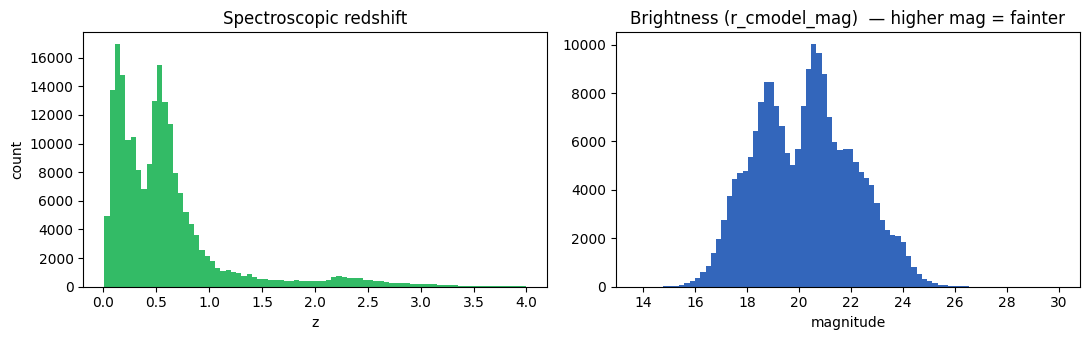

fraction with z < 0.5: 51.4%
fraction with z < 1.0: 87.8%
fraction with z < 1.5: 92.8%
median z: 0.489 | 95th pct z: 1.991


In [7]:
print("=== Summary statistics ===")
print(df.describe().T[["mean","std","min","25%","50%","75%","max"]], "\n")

# Data-quality checks (the 'careful data preparation' rubric point)
print("=== Quality checks ===")
print("NaNs per column:\n", df.isna().sum())
print("Negative/zero redshifts:", int((df[Z] <= 0).sum()))
# spot-check a few images for NaN/all-zero without loading everything
samp = np.sort(np.random.default_rng(0).choice(N, size=64, replace=False))
imgs = img[samp]
print("Sample image NaNs:", int(np.isnan(imgs).sum()), "| all-zero images:", int((imgs.reshape(len(samp),-1).sum(1)==0).sum()))

# Distributions
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
ax[0].hist(df[Z], bins=80, color="#3b6", edgecolor="none")
ax[0].set(title="Spectroscopic redshift", xlabel="z", ylabel="count")
if MAG:
    ax[1].hist(df[MAG].replace([np.inf,-np.inf], np.nan).dropna(), bins=80, color="#36b", edgecolor="none")
    ax[1].set(title=f"Brightness ({MAG})  — higher mag = fainter", xlabel="magnitude")
plt.tight_layout(); plt.show()

# Insights
for thr in (0.5, 1.0, 1.5):
    print(f"fraction with z < {thr}: {(df[Z] < thr).mean():.1%}")
print("median z:", round(float(df[Z].median()),3), "| 95th pct z:", round(float(df[Z].quantile(0.95)),3))

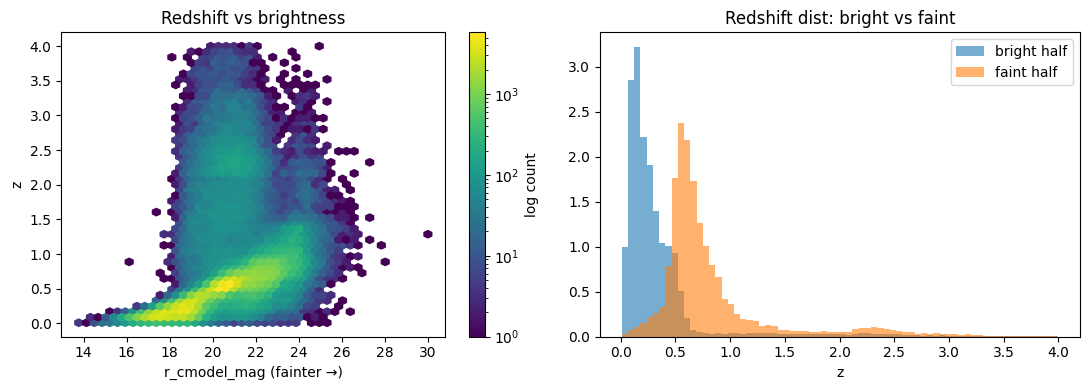

corr(mag, z) = +0.477
median z  — bright: 0.220  faint: 0.651
frac z>0.5 — bright: 13.3%  faint: 83.9%
KS distance (bright vs faint z-dist): 0.724


In [8]:
d = df[[Z, MAG]].replace([np.inf,-np.inf], np.nan).dropna()

fig, ax = plt.subplots(1, 2, figsize=(11,4))
hb = ax[0].hexbin(d[MAG], d[Z], gridsize=45, bins="log", cmap="viridis")
ax[0].set(title="Redshift vs brightness", xlabel=f"{MAG} (fainter →)", ylabel="z")
fig.colorbar(hb, ax=ax[0], label="log count")

# Bright vs faint split at the median magnitude — a preview of your train/test shift
cut = d[MAG].median()
bright = d[d[MAG] <= cut][Z]
faint  = d[d[MAG] >  cut][Z]
ax[1].hist(bright, bins=70, density=True, alpha=.6, label="bright half")
ax[1].hist(faint,  bins=70, density=True, alpha=.6, label="faint half")
ax[1].set(title="Redshift dist: bright vs faint", xlabel="z"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"corr(mag, z) = {d[MAG].corr(d[Z]):+.3f}")
print(f"median z  — bright: {bright.median():.3f}  faint: {faint.median():.3f}")
print(f"frac z>0.5 — bright: {(bright>0.5).mean():.1%}  faint: {(faint>0.5).mean():.1%}")
try:
    from scipy.stats import ks_2samp
    print("KS distance (bright vs faint z-dist):", round(ks_2samp(bright, faint).statistic,3))
except Exception as e:
    print("scipy KS skipped:", e)

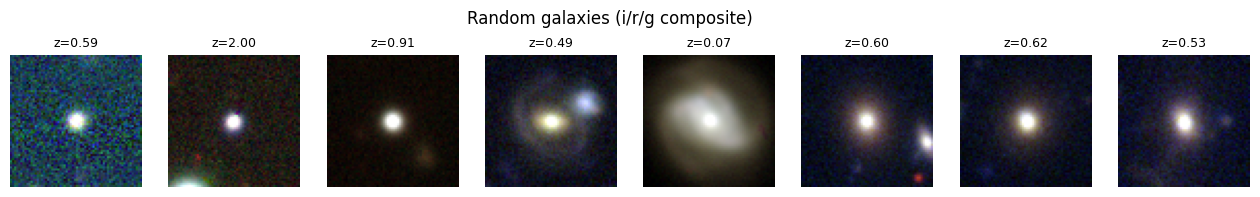

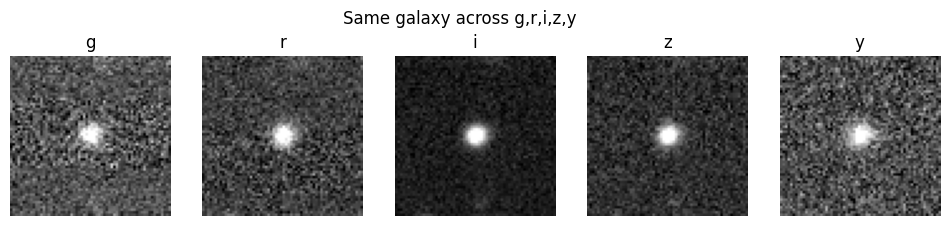

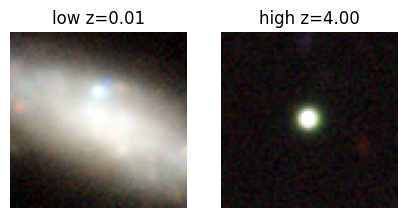

In [9]:
BANDS = ["g", "r", "i", "z", "y"]   

def get_image(i):
    a = img[i]
    return np.moveaxis(a, band_axis-1, -1)   # -> (64,64,5)

def stretch(x):                              # asinh, robust to negatives
    x = np.arcsinh(x.astype(np.float32))
    lo, hi = np.percentile(x, [1, 99.5])
    return np.clip((x - lo)/(hi - lo + 1e-8), 0, 1)

def rgb(i):                                  # i=R, r=G, g=B composite
    im = get_image(i)
    return np.stack([stretch(im[...,2]), stretch(im[...,1]), stretch(im[...,0])], -1)

# 8 random galaxies with their redshifts
idx = np.sort(np.random.default_rng(1).choice(N, 8, replace=False))
fig, ax = plt.subplots(1, 8, figsize=(16,2.3))
for a, i in zip(ax, idx):
    a.imshow(rgb(i)); a.set_title(f"z={df[Z][i]:.2f}", fontsize=9); a.axis("off")
plt.suptitle("Random galaxies (i/r/g composite)"); plt.show()

# Per-band view of one galaxy — shows what the 5 channels actually contain
one = get_image(idx[0])
fig, ax = plt.subplots(1, 5, figsize=(12,2.6))
for a, b in enumerate(BANDS):
    a_ = ax[a]; a_.imshow(stretch(one[...,a]), cmap="gray"); a_.set_title(b); a_.axis("off")
plt.suptitle("Same galaxy across g,r,i,z,y"); plt.show()

# Low-z vs high-z: why redshift is hard from images
lo_i = int(d[Z].idxmin()); hi_i = int(d[Z].idxmax())
fig, ax = plt.subplots(1, 2, figsize=(5,2.6))
ax[0].imshow(rgb(lo_i)); ax[0].set_title(f"low z={df[Z][lo_i]:.2f}"); ax[0].axis("off")
ax[1].imshow(rgb(hi_i)); ax[1].set_title(f"high z={df[Z][hi_i]:.2f}"); ax[1].axis("off")
plt.show()

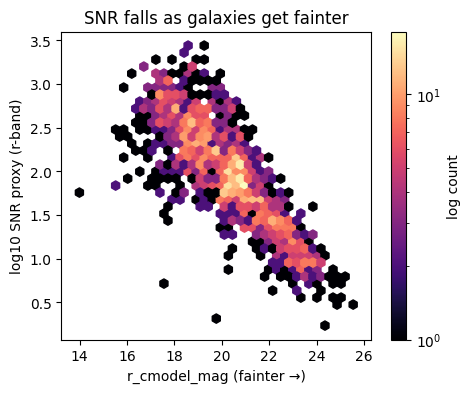

=== INSIGHTS SUMMARY ===
- 204,573 galaxies, target z in [0.01, 4.00], median 0.49
- redshift is heavily low-z skewed (93% below 1.5) -> outlier-aware metrics needed
- fainter galaxies -> higher z AND lower SNR -> bright→faint split is a genuine, hard shift


In [10]:
# SNR proxy on a sample: central peak / outer-region noise, per galaxy
s = np.sort(np.random.default_rng(2).choice(N, 1500, replace=False))
cube = img[s]                                   # ~120 MB, fine
cube = np.moveaxis(cube, band_axis, -1)         # (n,64,64,5)
r_band = cube[..., 1]                           # r
c = r_band[:, 28:36, 28:36].reshape(len(s), -1).max(1)     # central peak
bg = r_band[:, :8, :8].reshape(len(s), -1).std(1) + 1e-6   # corner noise
snr = c / bg

msnr = df[MAG].values[s]
ok = np.isfinite(msnr) & np.isfinite(snr)
plt.figure(figsize=(5,4))
plt.hexbin(msnr[ok], np.log10(snr[ok]+1e-6), gridsize=35, bins="log", cmap="magma")
plt.xlabel(f"{MAG} (fainter →)"); plt.ylabel("log10 SNR proxy (r-band)")
plt.title("SNR falls as galaxies get fainter"); plt.colorbar(label="log count"); plt.show()

print("=== INSIGHTS SUMMARY ===")
print(f"- {N:,} galaxies, target z in [{df[Z].min():.2f}, {df[Z].max():.2f}], median {df[Z].median():.2f}")
print(f"- redshift is heavily low-z skewed ({(df[Z]<1.5).mean():.0%} below 1.5) -> outlier-aware metrics needed")
print(f"- fainter galaxies -> higher z AND lower SNR -> bright→faint split is a genuine, hard shift")


h.close()

In [11]:


SEED = 42
rng = np.random.default_rng(SEED)

cands = glob.glob("/kaggle/input/**/*.hdf5", recursive=True) + glob.glob("/kaggle/input/**/*.h5", recursive=True)
PATH = [f for f in cands if "train" in f.lower()][0]
print("File:", PATH, f"({os.path.getsize(PATH)/1e9:.2f} GB)\n")

h5 = h5py.File(PATH, "r")
keys = list(h5.keys())

IMG_KEY = "image"
img = h5[IMG_KEY]
N = img.shape[0]
non_n = list(img.shape[1:])
BAND_AXIS = int(np.where(np.array(non_n) == 5)[0][0]) + 1   # +1: axis 0 is the galaxy index
print(f"image: shape={img.shape} dtype={img.dtype}  ->  N={N:,}, band axis={BAND_AXIS}")

s = np.sort(rng.choice(N, 32, replace=False))
samp = img[s]
print(f"image values (sample): min={float(samp.min()):.4g} max={float(samp.max()):.4g} mean={float(samp.mean()):.4g}\n")

def one_d_numeric(k):
    d = h5[k]; return d.ndim==1 and d.shape[0]==N and np.issubdtype(d.dtype, np.number)

# redshift target
z_pref = ["specz_redshift","redshift","specz","spec_z","z_spec"]
TARGET = next((k for k in z_pref if k in keys and one_d_numeric(k)), None)
if TARGET is None:
    TARGET = next((k for k in keys if one_d_numeric(k) and "red" in k.lower()), None)

# brightness axis for the split
MAG = "r_cmodel_mag" if "r_cmodel_mag" in keys else \
      next((k for k in keys if one_d_numeric(k) and k.endswith("cmodel_mag")), None)

print("TARGET (redshift):", TARGET)
print("MAG (brightness) :", MAG)
assert TARGET is not None, "No redshift column found — paste `keys` and I'll fix the detector."
assert MAG is not None,   "No magnitude column found — tell me which to use."

zt, mg = h5[TARGET][:], h5[MAG][:]
print(f"\n{TARGET}: min={np.nanmin(zt):.3f} max={np.nanmax(zt):.3f} median={np.nanmedian(zt):.3f}   <- should be ~0–4")
print(f"{MAG}: min={np.nanmin(mg):.3f} max={np.nanmax(mg):.3f} median={np.nanmedian(mg):.3f}   <- should be ~14–25")
print("\nAll keys:\n", keys)

File: /kaggle/input/datasets/dfonseca218/redshift/5x64x64_training_with_morphology.hdf5 (16.93 GB)

image: shape=(204573, 5, 64, 64) dtype=float32  ->  N=204,573, band axis=1
image values (sample): min=-2.459 max=264.5 mean=0.916

TARGET (redshift): specz_redshift
MAG (brightness) : r_cmodel_mag

specz_redshift: min=0.010 max=3.998 median=0.489   <- should be ~0–4
r_cmodel_mag: min=13.769 max=30.007 median=20.310   <- should be ~14–25

All keys:
 ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak

In [12]:
num_cols = [k for k in keys if one_d_numeric(k)]
df = pd.DataFrame({k: h5[k][:] for k in num_cols})
n0 = len(df)
mask = np.ones(n0, dtype=bool)

def drop(cond, name):
    global mask
    c = cond & mask
    print(f"  drop {int(c.sum()):>6} : {name}")
    mask &= ~cond

drop(~np.isfinite(df[TARGET].values), "non-finite redshift")
drop(df[TARGET].values <= 0,          "redshift <= 0")
drop(df[TARGET].values > 4.0,         "redshift > 4 (outside design range)")
drop(~np.isfinite(df[MAG].values),    "non-finite r-mag")

for sc in [k for k in num_cols if k.endswith("magsigma")]:   # the broken y-band lives here
    drop(df[sc].values > 1.0, f"{sc} > 1.0 (bad/unmeasured band)")

clean_idx = np.where(mask)[0]
print(f"\nKept {len(clean_idx):,} / {n0:,}  ({len(clean_idx)/n0:.1%})")

chk = np.sort(rng.choice(clean_idx, min(2000, len(clean_idx)), replace=False))
flat = img[chk].reshape(len(chk), -1)
print("sample NaN images:", int(np.isnan(flat).any(1).sum()),
      "| sample all-zero images:", int((flat==0).all(1).sum()))

  drop      0 : non-finite redshift
  drop      0 : redshift <= 0
  drop      0 : redshift > 4 (outside design range)
  drop      0 : non-finite r-mag
  drop     13 : g_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop      1 : i_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop      0 : r_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop     10 : y_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop      4 : z_cmodel_magsigma > 1.0 (bad/unmeasured band)

Kept 204,545 / 204,573  (100.0%)
sample NaN images: 0 | sample all-zero images: 0


In [13]:
mag_clean = df[MAG].values[clean_idx]
CUT = np.median(mag_clean)                 # knob: median r-mag; >= CUT is "faint"
print(f"brightness cut = {CUT:.3f}\n")

bright_pool = clean_idx[mag_clean <  CUT].copy()
faint_pool  = clean_idx[mag_clean >= CUT].copy()
rng.shuffle(bright_pool); rng.shuffle(faint_pool)

nb = len(bright_pool)
n_tr, n_va, n_ca = int(0.65*nb), int(0.10*nb), int(0.10*nb)
idx_train       = np.sort(bright_pool[:n_tr])
idx_val         = np.sort(bright_pool[n_tr:n_tr+n_va])
idx_calib       = np.sort(bright_pool[n_tr+n_va:n_tr+n_va+n_ca])   # for conformal later
idx_bright_test = np.sort(bright_pool[n_tr+n_va+n_ca:])            # in-distribution test
idx_faint_test  = np.sort(faint_pool)                             # OOD test

for nm, ix in [("train",idx_train),("val",idx_val),("calib",idx_calib),
               ("bright_test (in-dist)",idx_bright_test),("faint_test (OOD)",idx_faint_test)]:
    print(f"  {nm:24} {len(ix):>7,}")

zb, zf = df[TARGET].values[idx_bright_test], df[TARGET].values[idx_faint_test]
print(f"\nmedian z   bright={np.median(zb):.3f}  faint={np.median(zf):.3f}")
print(f"frac z>0.5 bright={(zb>0.5).mean():.1%}  faint={(zf>0.5).mean():.1%}")
try:
    from scipy.stats import ks_2samp
    print("KS distance (bright vs faint z):", round(ks_2samp(zb, zf).statistic, 3), " <- bigger = stronger shift")
except Exception as e:
    print("KS skipped:", e)

np.savez("/kaggle/working/splits.npz",
         idx_train=idx_train, idx_val=idx_val, idx_calib=idx_calib,
         idx_bright_test=idx_bright_test, idx_faint_test=idx_faint_test,
         TARGET=TARGET, MAG=MAG, CUT=CUT, BAND_AXIS=BAND_AXIS)
print("\nsaved -> /kaggle/working/splits.npz")


brightness cut = 20.309

  train                     66,476
  val                       10,227
  calib                     10,227
  bright_test (in-dist)     15,342
  faint_test (OOD)         102,273

median z   bright=0.220  faint=0.651
frac z>0.5 bright=13.1%  faint=83.8%
KS distance (bright vs faint z): 0.724  <- bigger = stronger shift

saved -> /kaggle/working/splits.npz


In [14]:
def to_hwc(a): return np.moveaxis(a, BAND_AXIS, -1)   # -> (batch, H, W, 5)

CHUNK, n_seen = 512, 0
s1 = np.zeros(5, np.float64); s2 = np.zeros(5, np.float64)
for i in range(0, len(idx_train), CHUNK):
    x = np.arcsinh(to_hwc(img[idx_train[i:i+CHUNK]]).astype(np.float32)).reshape(-1, 5)
    s1 += x.sum(0); s2 += (x**2).sum(0); n_seen += x.shape[0]
    if i % (CHUNK*40) == 0: print(f"  {i:>7}/{len(idx_train)}")

BAND_MEAN = (s1/n_seen).astype(np.float32)
BAND_STD  = np.sqrt(np.maximum(s2/n_seen - (s1/n_seen)**2, 1e-12)).astype(np.float32)
print("per-band mean:", np.round(BAND_MEAN,3))
print("per-band std :", np.round(BAND_STD,3))
np.savez("/kaggle/working/norm.npz", BAND_MEAN=BAND_MEAN, BAND_STD=BAND_STD)
print("saved -> /kaggle/working/norm.npz")

        0/66476
    20480/66476
    40960/66476
    61440/66476
per-band mean: [0.267 0.457 0.575 0.671 0.755]
per-band std : [0.481 0.677 0.792 0.873 0.943]
saved -> /kaggle/working/norm.npz


In [15]:
d = np.load("/kaggle/working/splits.npz", allow_pickle=True)
idx_faint_test_full = d["idx_faint_test"]

# subsample faint_test to ~18k for balanced, fast evaluation
rng = np.random.default_rng(42)
keep = rng.choice(len(idx_faint_test_full), size=min(18000, len(idx_faint_test_full)), replace=False)
idx_faint_test = np.sort(idx_faint_test_full[keep])

# also build brightness bins across BOTH test sets — for the "coverage vs brightness" money plot
mag_all = h5[str(d["MAG"])][:]
test_all = np.concatenate([d["idx_bright_test"], idx_faint_test])
mags_test = mag_all[test_all]
bin_edges = np.quantile(mags_test, np.linspace(0, 1, 7))   # 6 brightness bins
print("brightness bin edges (r-mag):", np.round(bin_edges, 2))

np.savez("/kaggle/working/splits.npz",
         idx_train=d["idx_train"], idx_val=d["idx_val"], idx_calib=d["idx_calib"],
         idx_bright_test=d["idx_bright_test"],
         idx_faint_test=idx_faint_test,
         idx_faint_test_full=idx_faint_test_full,   # kept in case you want the full pile later
         test_bin_edges=bin_edges,
         TARGET=str(d["TARGET"]), MAG=str(d["MAG"]), CUT=float(d["CUT"]), BAND_AXIS=int(d["BAND_AXIS"]))
print(f"faint_test trimmed: {len(idx_faint_test_full):,} -> {len(idx_faint_test):,}")
print(f"bright_test: {len(d['idx_bright_test']):,}  |  now balanced for evaluation")

brightness bin edges (r-mag): [14.35 18.43 19.37 20.48 21.18 22.32 26.72]
faint_test trimmed: 102,273 -> 18,000
bright_test: 15,342  |  now balanced for evaluation


In [16]:
import torch, numpy as np, h5py
from torch.utils.data import Dataset, DataLoader

d = np.load("/kaggle/working/splits.npz", allow_pickle=True)
TARGET = str(d["TARGET"]); MAG = str(d["MAG"]); BAND_AXIS = int(d["BAND_AXIS"])
idx_train, idx_val, idx_calib = d["idx_train"], d["idx_val"], d["idx_calib"]
idx_bright_test, idx_faint_test = d["idx_bright_test"], d["idx_faint_test"]
nrm = np.load("/kaggle/working/norm.npz")
BAND_MEAN, BAND_STD = nrm["BAND_MEAN"], nrm["BAND_STD"]

class GalaxyDS(Dataset):
    """Reads 5x64x64 cutouts lazily. asinh -> per-band standardize. Returns (image, z)."""
    def __init__(self, path, indices, target, band_axis, mean, std, augment=False):
        self.path, self.indices = path, np.asarray(indices)
        self.target, self.band_axis = target, band_axis
        self.mean = mean.reshape(5,1,1); self.std = std.reshape(5,1,1)
        self.augment = augment
        self.h5 = None  # opened per-worker

    def __len__(self): return len(self.indices)

    def _ensure_open(self):
        if self.h5 is None:
            self.h5 = h5py.File(self.path, "r")
            self.img = self.h5["image"]; self.z = self.h5[self.target]

    def __getitem__(self, i):
        self._ensure_open()
        j = int(self.indices[i])
        a = self.img[j]                                   # raw cutout
        a = np.moveaxis(a, self.band_axis-1, 0)           # -> (5, H, W)
        a = np.arcsinh(a.astype(np.float32))
        a = (a - self.mean) / self.std
        if self.augment:                                  # galaxies have no "up"
            if np.random.rand() < 0.5: a = a[:, ::-1, :]
            if np.random.rand() < 0.5: a = a[:, :, ::-1]
            a = np.rot90(a, k=np.random.randint(4), axes=(1,2))
        x = torch.from_numpy(np.ascontiguousarray(a))
        y = torch.tensor(float(self.z[j]), dtype=torch.float32)
        return x, y

def make_loader(indices, batch=256, shuffle=False, augment=False, workers=2):
    ds = GalaxyDS(PATH, indices, TARGET, BAND_AXIS, BAND_MEAN, BAND_STD, augment)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=workers,
                      pin_memory=True, drop_last=shuffle, persistent_workers=False)   # FIX

train_loader = make_loader(idx_train, shuffle=True, augment=True)
val_loader   = make_loader(idx_val)
xb, yb = next(iter(train_loader))
print("batch images:", tuple(xb.shape), "| targets:", tuple(yb.shape))
print("image mean≈0? ", float(xb.mean()).__round__(3), " std≈1? ", float(xb.std()).__round__(3))

batch images: (256, 5, 64, 64) | targets: (256,)
image mean≈0?  0.04  std≈1?  1.011


In [17]:
import torch.nn as nn, torch.nn.functional as F

class HeteroCNN(nn.Module):
    """Outputs mu and log-variance for p(z|image) = Normal(mu, sigma^2)."""
    def __init__(self, in_ch=5, width=32):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(in_ch, width), block(width, width*2),
            block(width*2, width*4), block(width*4, width*4))   # 64 -> 4x4
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Linear(width*4, 128), nn.ReLU(), nn.Dropout(0.2))
        self.mu      = nn.Linear(128, 1)
        self.logvar  = nn.Linear(128, 1)

    def forward(self, x):
        f = self.head(self.features(x))
        mu = self.mu(f).squeeze(1)
        logvar = torch.clamp(self.logvar(f).squeeze(1), -10, 6)  # keep sigma sane
        return mu, logvar

def gaussian_nll(mu, logvar, y):
    # -log N(y | mu, exp(logvar)); the 0.5*logvar term punishes lazy over-confidence
    return (0.5*logvar + 0.5*(y-mu)**2/torch.exp(logvar)).mean()

device = "cuda" if torch.cuda.is_available() else "cpu"
model = HeteroCNN().to(device)
print(model.__class__.__name__, "| params:",
      sum(p.numel() for p in model.parameters())/1e6, "M | device:", device)

HeteroCNN | params: 0.60093 M | device: cuda


In [18]:
import time, copy

EPOCHS = 30
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
CKPT = "/kaggle/working/hetero_cnn.pt"

def run_epoch(loader, train=True):
    model.train(train)
    tot, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.set_grad_enabled(train):
            mu, logvar = model(x)
            loss = gaussian_nll(mu, logvar, y)
            if train:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
        tot += loss.item()*len(y); n += len(y)
    return tot/n

best, best_state, hist = float("inf"), None, []
start = 0
# resume if a checkpoint exists (after a session timeout)
if os.path.exists(CKPT):
    ck = torch.load(CKPT, map_location=device)
    model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
    sched.load_state_dict(ck["sched"])                                               # FIX
    start, best, hist, best_state = ck["epoch"]+1, ck["best"], ck["hist"], ck["best_state"]   # FIX
    print(f"resumed from epoch {start}, best val {best:.4f}")

for ep in range(start, EPOCHS):
    t = time.time()
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    sched.step()
    hist.append((ep, tr, va))
    if va < best:
        best, best_state = va, copy.deepcopy(model.state_dict())
    torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                "sched": sched.state_dict(),                                          # FIX
                "epoch": ep, "best": best, "hist": hist,
                "best_state": best_state}, CKPT)
    print(f"epoch {ep:2d} | train {tr:.4f} | val {va:.4f} | best {best:.4f} | {time.time()-t:.0f}s")

print("done. best val NLL:", round(best,4))

epoch  0 | train -1.5967 | val -1.0049 | best -1.0049 | 43s
epoch  1 | train -2.0254 | val -2.3704 | best -2.3704 | 30s
epoch  2 | train -2.0968 | val -2.4515 | best -2.4515 | 31s
epoch  3 | train -2.2157 | val -2.3237 | best -2.4515 | 32s
epoch  4 | train -2.2590 | val -2.4511 | best -2.4515 | 32s
epoch  5 | train -2.2888 | val -2.3276 | best -2.4515 | 32s
epoch  6 | train -2.2347 | val -2.1844 | best -2.4515 | 32s
epoch  7 | train -2.2507 | val -2.5707 | best -2.5707 | 32s
epoch  8 | train -2.3646 | val -2.3161 | best -2.5707 | 32s
epoch  9 | train -2.2882 | val -2.6285 | best -2.6285 | 32s
epoch 10 | train -2.4044 | val -2.5155 | best -2.6285 | 32s
epoch 11 | train -2.3995 | val -2.5979 | best -2.6285 | 32s
epoch 12 | train -2.4090 | val -2.5287 | best -2.6285 | 32s
epoch 13 | train -2.4242 | val -2.3034 | best -2.6285 | 32s
epoch 14 | train -2.5052 | val -2.8198 | best -2.8198 | 32s
epoch 15 | train -2.4611 | val -2.7075 | best -2.8198 | 32s
epoch 16 | train -2.5351 | val -2.8004 |

In [19]:

from scipy import stats

# reload best weights
ck = torch.load(CKPT, map_location=device)
model.load_state_dict(ck["best_state"])
model.eval()
print(f"loaded best_state (val NLL {ck['best']:.4f})")

d = np.load("/kaggle/working/splits.npz", allow_pickle=True)
MAG = str(d["MAG"])
mag_all = h5[MAG][:]

@torch.no_grad()
def predict(indices):
    loader = make_loader(indices, batch=512, shuffle=False, augment=False)
    mus, sigmas, ys = [], [], []
    for x, y in loader:
        mu, logvar = model(x.to(device))
        mus.append(mu.cpu().numpy())
        sigmas.append(np.exp(0.5*logvar.cpu().numpy()))   # sigma = sqrt(var)
        ys.append(y.numpy())
    return np.concatenate(mus), np.concatenate(sigmas), np.concatenate(ys)

results = {}
for name, ix in [("bright", d["idx_bright_test"]), ("faint", d["idx_faint_test"])]:
    mu, sig, y = predict(ix)
    results[name] = {"mu": mu, "sigma": sig, "z": y, "mag": mag_all[ix]}
    print(f"{name}: {len(y):,} galaxies predicted")

np.savez("/kaggle/working/preds.npz", **{
    f"{n}_{k}": results[n][k] for n in results for k in results[n]})
print("saved -> /kaggle/working/preds.npz")

loaded best_state (val NLL -2.9573)
bright: 15,342 galaxies predicted
faint: 18,000 galaxies predicted
saved -> /kaggle/working/preds.npz


In [20]:
def metrics(mu, sigma, z):
    dz = (mu - z) / (1 + z)                      # normalized residual
    bias   = np.mean(dz)
    sigmad = 1.4826 * np.median(np.abs(dz - np.median(dz)))   # robust scatter
    outl   = np.mean(np.abs(dz) > 0.15)          # catastrophic-outlier fraction
    # calibration: does the model's claimed interval contain the truth as often as it says?
    z_score = (z - mu) / sigma
    cov68 = np.mean(np.abs(z_score) <= 1.0)      # should be ~0.68 if honest
    cov95 = np.mean(np.abs(z_score) <= 1.960)    # should be ~0.95 if honest
    pit   = stats.norm.cdf(z_score)              # PIT values; uniform if calibrated
    pit_ks = stats.kstest(pit, "uniform").statistic   # 0 = perfectly calibrated
    return bias, sigmad, outl, cov68, cov95, pit_ks

print(f"{'metric':<24}{'bright (in-dist)':>18}{'faint (OOD)':>16}")
print("-"*58)
labels = ["bias (→0)", "sigma_MAD (↓)", "outlier frac (↓)",
          "68% coverage (→.68)", "95% coverage (→.95)", "PIT KS (→0, ↓ better)"]
mb = metrics(**{k: results["bright"][k] for k in ("mu","sigma","z")})
mf = metrics(**{k: results["faint"][k]  for k in ("mu","sigma","z")})
for lab, b, f in zip(labels, mb, mf):
    print(f"{lab:<24}{b:>18.4f}{f:>16.4f}")

print("\nRead: accuracy (top 3) degrades on faint — expected.")
print("The story is coverage: if 68%/95% coverage collapses below target on faint,")
print("the model is confidently wrong — that's the miscalibration conformal will fix.")

metric                    bright (in-dist)     faint (OOD)
----------------------------------------------------------
bias (→0)                           0.0003          0.0211
sigma_MAD (↓)                       0.0168          0.0916
outlier frac (↓)                    0.0422          0.2945
68% coverage (→.68)                 0.8426          0.7530
95% coverage (→.95)                 0.9822          0.9528
PIT KS (→0, ↓ better)               0.1448          0.1110

Read: accuracy (top 3) degrades on faint — expected.
The story is coverage: if 68%/95% coverage collapses below target on faint,
the model is confidently wrong — that's the miscalibration conformal will fix.


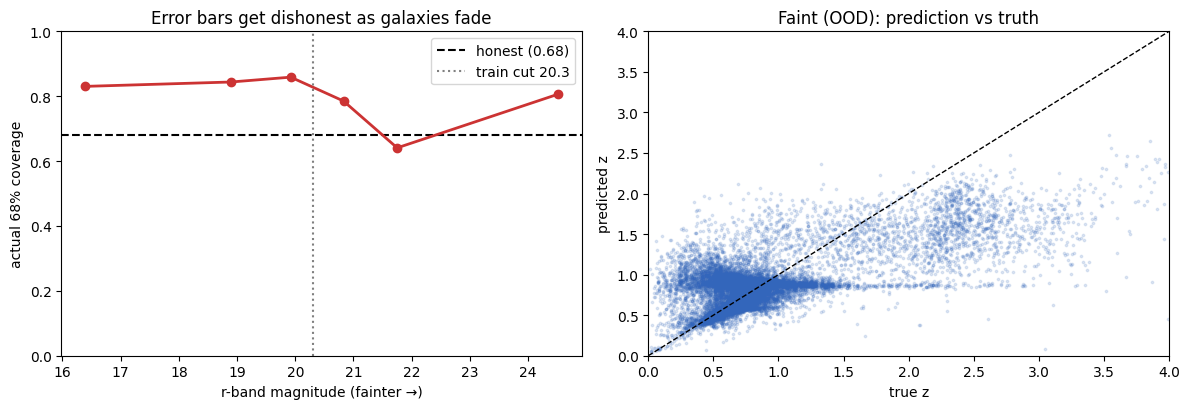

Left plot is the headline: if the red line sags below the dashed line on the
faint (right) side, the model's 68% intervals contain the truth far less than 68%
of the time — confidently wrong exactly where we expected.


In [21]:
import matplotlib.pyplot as plt

# pool both test sets, bin by brightness, measure actual 68% coverage per bin
mu  = np.concatenate([results["bright"]["mu"],    results["faint"]["mu"]])
sig = np.concatenate([results["bright"]["sigma"], results["faint"]["sigma"]])
z   = np.concatenate([results["bright"]["z"],     results["faint"]["z"]])
mag = np.concatenate([results["bright"]["mag"],   results["faint"]["mag"]])

edges = d["test_bin_edges"]
centers, cov68_bin, counts = [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (mag >= lo) & (mag < hi)
    if m.sum() < 50: continue
    zc = (z[m] - mu[m]) / sig[m]
    cov68_bin.append(np.mean(np.abs(zc) <= 1.0))
    centers.append(0.5*(lo+hi)); counts.append(int(m.sum()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) honesty vs brightness
ax[0].axhline(0.68, ls="--", c="k", label="honest (0.68)")
ax[0].plot(centers, cov68_bin, "o-", c="#c33", lw=2)
ax[0].axvline(float(d["CUT"]), ls=":", c="gray", label=f"train cut {float(d['CUT']):.1f}")
ax[0].set(xlabel="r-band magnitude (fainter →)", ylabel="actual 68% coverage",
          title="Error bars get dishonest as galaxies fade")
ax[0].legend(); ax[0].set_ylim(0, 1)

# (b) predicted vs true, faint set — where it breaks
f = results["faint"]
ax[1].scatter(f["z"], f["mu"], s=3, alpha=0.15, c="#36b")
lim = [0, 4]; ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set(xlim=lim, ylim=lim, xlabel="true z", ylabel="predicted z",
          title="Faint (OOD): prediction vs truth")
plt.tight_layout(); plt.savefig("/kaggle/working/money_plot.png", dpi=130); plt.show()

print("Left plot is the headline: if the red line sags below the dashed line on the")
print("faint (right) side, the model's 68% intervals contain the truth far less than 68%")
print("of the time — confidently wrong exactly where we expected.")

**we start the big training here**

In [22]:
import numpy as np, h5py
from scipy.ndimage import gaussian_filter1d

d = np.load("/kaggle/working/splits.npz", allow_pickle=True)
TARGET, MAG, BAND_AXIS = str(d["TARGET"]), str(d["MAG"]), int(d["BAND_AXIS"])
idx_train, idx_val, idx_calib = d["idx_train"], d["idx_val"], d["idx_calib"]
idx_bright_test, idx_faint_test = d["idx_bright_test"], d["idx_faint_test"]

MAG_COLS = ["g_cmodel_mag","r_cmodel_mag","i_cmodel_mag","z_cmodel_mag","y_cmodel_mag"]
mags = np.stack([h5[c][:] for c in MAG_COLS], axis=1).astype(np.float32)   # (N,5)
colors = np.stack([mags[:,0]-mags[:,1], mags[:,1]-mags[:,2],
                   mags[:,2]-mags[:,3], mags[:,3]-mags[:,4]], axis=1)      # g-r,r-i,i-z,z-y
PHOT = np.concatenate([mags, colors], axis=1)                             # (N,9)
PHOT = np.nan_to_num(PHOT, nan=0.0, posinf=0.0, neginf=0.0)

# standardize using TRAIN stats only
pm, ps = PHOT[idx_train].mean(0), PHOT[idx_train].std(0) + 1e-6
PHOT = np.clip((PHOT - pm) / ps, -5, 5).astype(np.float32)
print("photometry matrix:", PHOT.shape, "| feature means (train ~0):", np.round(PHOT[idx_train].mean(0),2))

# redshift bins for the PDF head
NUM_BINS = 200
Z_MIN, Z_MAX = 0.0, 4.0
edges   = np.linspace(Z_MIN, Z_MAX, NUM_BINS+1, dtype=np.float32)
CENTERS = ((edges[:-1] + edges[1:]) / 2).astype(np.float32)
BINW = CENTERS[1] - CENTERS[0]
print(f"{NUM_BINS} bins over [{Z_MIN},{Z_MAX}], width={BINW:.3f}")

# LDS imbalance weights: down-weight the common low-z bins, up-weight the sparse tail
ztr = h5[TARGET][:][idx_train]
hist, _ = np.histogram(ztr, bins=edges)
smooth = gaussian_filter1d(hist.astype(np.float64), sigma=2.0) + 1e-3   # smoothed label density
bin_w = 1.0 / np.sqrt(smooth)                                           # sqrt tempers the tail
bin_w = (bin_w / (bin_w[np.clip(np.digitize(ztr, edges)-1,0,NUM_BINS-1)]).mean()).astype(np.float32)  # mean≈1 over train
LDS_BIN_W = bin_w
print("LDS weight range:", np.round(LDS_BIN_W.min(),2), "->", np.round(LDS_BIN_W.max(),2),
      "(low-z ~small, high-z ~large)")

np.savez("/kaggle/working/multimodal_setup.npz",
         PHOT=PHOT, CENTERS=CENTERS, edges=edges, LDS_BIN_W=LDS_BIN_W, NUM_BINS=NUM_BINS)

photometry matrix: (204573, 9) | feature means (train ~0): [-0.  0. -0. -0. -0. -0.  0.  0.  0.]
200 bins over [0.0,4.0], width=0.020
LDS weight range: 0.49 -> 28.33 (low-z ~small, high-z ~large)


capping patch

In [23]:
# cap extreme LDS weights, then renormalize to mean 1 over training samples
w = LDS_BIN_W.copy().astype(np.float64)
ztr = h5[TARGET][:][idx_train]
b = np.clip(np.digitize(ztr, edges) - 1, 0, NUM_BINS - 1)
w = np.clip(w, None, 10.0)
w = w / w[b].mean()
LDS_BIN_W = w.astype(np.float32)
ldsw_t = torch.tensor(LDS_BIN_W, device=device)   # refresh tensor used by loss_fn
print("capped LDS weight range:", round(float(LDS_BIN_W.min()),2), "->", round(float(LDS_BIN_W.max()),2))
np.savez("/kaggle/working/multimodal_setup.npz",
         PHOT=PHOT, CENTERS=CENTERS, edges=edges, LDS_BIN_W=LDS_BIN_W, NUM_BINS=NUM_BINS)

capped LDS weight range: 0.5 -> 10.1


In [24]:
import torch
from torch.utils.data import Dataset, DataLoader

nrm = np.load("/kaggle/working/norm.npz")
BAND_MEAN, BAND_STD = nrm["BAND_MEAN"].reshape(5,1,1), nrm["BAND_STD"].reshape(5,1,1)

class MMGalaxy(Dataset):
    def __init__(self, path, indices, augment=False):
        self.path, self.indices, self.augment = path, np.asarray(indices), augment
        self.h5 = None
    def __len__(self): return len(self.indices)
    def _open(self):
        if self.h5 is None:
            self.h5 = h5py.File(self.path, "r"); self.img = self.h5["image"]; self.z = self.h5[TARGET]
    def __getitem__(self, i):
        self._open(); j = int(self.indices[i])
        a = np.moveaxis(self.img[j], BAND_AXIS-1, 0)            # -> (5,H,W)
        a = (np.arcsinh(a.astype(np.float32)) - BAND_MEAN) / BAND_STD
        if self.augment:
            if np.random.rand()<0.5: a = a[:,::-1,:]
            if np.random.rand()<0.5: a = a[:,:,::-1]
            a = np.rot90(a, np.random.randint(4), axes=(1,2))
        x_img = torch.from_numpy(np.ascontiguousarray(a))
        x_phot = torch.from_numpy(PHOT[j])
        y = torch.tensor(float(self.z[j]), dtype=torch.float32)
        return x_img, x_phot, y

def mm_loader(ix, batch=256, shuffle=False, augment=False, workers=2, persist=False):
    ds = MMGalaxy(PATH, ix, augment)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=workers,
                      pin_memory=True, drop_last=shuffle, persistent_workers=False)   # FIX

train_loader = mm_loader(idx_train, shuffle=True, augment=True)
val_loader   = mm_loader(idx_val)
xi, xp, yy = next(iter(train_loader))
print("img", tuple(xi.shape), "| phot", tuple(xp.shape), "| y", tuple(yy.shape),
      "| img mean≈0:", round(float(xi.mean()),3))

img (256, 5, 64, 64) | phot (256, 9) | y (256,) | img mean≈0: 0.007


In [25]:
import torch.nn as nn, torch.nn.functional as F

class SEBlock(nn.Module):                       # channel attention: lets the net emphasize informative bands/features
    def __init__(self, c, r=8):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(c, c//r), nn.ReLU(), nn.Linear(c//r, c), nn.Sigmoid())
    def forward(self, x):
        s = x.mean((2,3)); s = self.fc(s).unsqueeze(-1).unsqueeze(-1); return x*s

class ResBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.c1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False); self.b1 = nn.BatchNorm2d(cout)
        self.c2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False);     self.b2 = nn.BatchNorm2d(cout)
        self.se = SEBlock(cout)
        self.short = nn.Sequential() if (stride==1 and cin==cout) else \
                     nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))
    def forward(self, x):
        h = F.relu(self.b1(self.c1(x))); h = self.se(self.b2(self.c2(h)))
        return F.relu(h + self.short(x))

class MultiModalPhotoZ(nn.Module):
    def __init__(self, num_bins, in_ch=5, phot_dim=9, use_phot=True):
        super().__init__()
        self.use_phot = use_phot
        self.stem = nn.Sequential(nn.Conv2d(in_ch, 32, 3, 1, 1, bias=False), nn.BatchNorm2d(32), nn.ReLU())
        self.stage1 = nn.Sequential(ResBlock(32,32),  ResBlock(32,64,2))    # 64->32
        self.stage2 = nn.Sequential(ResBlock(64,64),  ResBlock(64,128,2))   # 32->16
        self.stage3 = nn.Sequential(ResBlock(128,128),ResBlock(128,256,2))  # 16->8
        self.stage4 = nn.Sequential(ResBlock(256,256),ResBlock(256,256,2))  # 8->4
        self.img_out = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten())  # 256-d
        self.phot = nn.Sequential(nn.Linear(phot_dim,64), nn.ReLU(), nn.BatchNorm1d(64),
                                  nn.Linear(64,64), nn.ReLU()) if use_phot else None
        fuse_dim = 256 + (64 if use_phot else 0)
        self.head = nn.Sequential(nn.Linear(fuse_dim,256), nn.ReLU(), nn.Dropout(0.3),
                                  nn.Linear(256, num_bins))
    def forward(self, x_img, x_phot):
        f = self.img_out(self.stage4(self.stage3(self.stage2(self.stage1(self.stem(x_img))))))
        if self.use_phot: f = torch.cat([f, self.phot(x_phot)], dim=1)
        return self.head(f)                     # logits over bins

device = "cuda" if torch.cuda.is_available() else "cpu"
USE_PHOT = True        # ablation flag: False = image-only binned model
model = MultiModalPhotoZ(NUM_BINS, use_phot=USE_PHOT).to(device)
print("params:", round(sum(p.numel() for p in model.parameters())/1e6,2), "M | use_phot:", USE_PHOT)

params: 4.22 M | use_phot: True


In [26]:
import time, copy
centers_t = torch.tensor(CENTERS, device=device)
edges_t   = torch.tensor(edges, device=device)
ldsw_t    = torch.tensor(LDS_BIN_W, device=device)
SOFT_SIGMA = 1.5 * BINW          # width of the soft label bump
USE_LDS = True                   # ablation flag: False = no imbalance weighting

def soft_targets(z):             # Gaussian label smoothing in redshift space -> (B, num_bins)
    diff = centers_t.unsqueeze(0) - z.unsqueeze(1)
    t = torch.exp(-0.5*(diff/SOFT_SIGMA)**2)
    return t / (t.sum(1, keepdim=True) + 1e-8)

def loss_fn(logits, z):
    logp = F.log_softmax(logits, dim=1)
    ce = -(soft_targets(z) * logp).sum(1)                       # per-sample soft cross-entropy
    if USE_LDS:
        b = torch.clamp(torch.bucketize(z, edges_t) - 1, 0, NUM_BINS-1)
        ce = ce * ldsw_t[b]
    return ce.mean()

@torch.no_grad()
def pdf_stats(logits):           # point estimate = E[z]; also PDF std for uncertainty
    p = F.softmax(logits, dim=1)
    mean = (p * centers_t).sum(1)
    var = (p * centers_t**2).sum(1) - mean**2
    return mean, torch.sqrt(torch.clamp(var, min=1e-8))

def val_sigma_mad():             # validation metric that matches our goal (robust scatter)
    model.eval(); dzs=[]
    with torch.no_grad():
        for xi, xp, y in val_loader:
            mu,_ = pdf_stats(model(xi.to(device), xp.to(device)))
            dz = (mu.cpu().numpy() - y.numpy())/(1+y.numpy()); dzs.append(dz)
    dz = np.concatenate(dzs); return 1.4826*np.median(np.abs(dz-np.median(dz)))

EPOCHS = 45                      # FIX (optional): same as the ablation's "full" run
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
CKPT = "/kaggle/working/mm_photoz.pt"
best, best_state, hist, start = 1e9, None, [], 0
if os.path.exists(CKPT):
    ck = torch.load(CKPT, map_location=device)
    model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
    sched.load_state_dict(ck["sched"])                                               # FIX
    start, best, hist, best_state = ck["epoch"]+1, ck["best"], ck["hist"], ck["best_state"]
    print(f"resumed @ epoch {start}, best sigma_MAD {best:.4f}")

for ep in range(start, EPOCHS):
    model.train(); t=time.time(); tot=n=0
    for xi, xp, y in train_loader:
        xi,xp,y = xi.to(device),xp.to(device),y.to(device)
        loss = loss_fn(model(xi,xp), y)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
        tot += loss.item()*len(y); n += len(y)
    sched.step()
    smad = float(val_sigma_mad()); hist.append((ep, tot/n, smad))                   # FIX: plain float
    if smad < best: best, best_state = smad, copy.deepcopy(model.state_dict())
    torch.save({"model":model.state_dict(),"opt":opt.state_dict(),
                "sched":sched.state_dict(),                                          # FIX
                "epoch":ep,"best":best,"best_state":best_state,"hist":hist,
                "USE_PHOT":USE_PHOT,"USE_LDS":USE_LDS}, CKPT)
    print(f"ep {ep:2d} | loss {tot/n:.4f} | val σ_MAD {smad:.4f} | best {best:.4f} | {time.time()-t:.0f}s")
print("done. best val σ_MAD:", round(best,4))

ep  0 | loss 3.4656 | val σ_MAD 0.0347 | best 0.0347 | 81s
ep  1 | loss 2.8919 | val σ_MAD 0.0322 | best 0.0322 | 80s
ep  2 | loss 2.7738 | val σ_MAD 0.0419 | best 0.0322 | 80s
ep  3 | loss 2.7175 | val σ_MAD 0.0201 | best 0.0201 | 80s
ep  4 | loss 2.6846 | val σ_MAD 0.0178 | best 0.0178 | 80s
ep  5 | loss 2.6606 | val σ_MAD 0.0188 | best 0.0178 | 80s
ep  6 | loss 2.6396 | val σ_MAD 0.0210 | best 0.0178 | 80s
ep  7 | loss 2.6246 | val σ_MAD 0.0204 | best 0.0178 | 79s
ep  8 | loss 2.6028 | val σ_MAD 0.0232 | best 0.0178 | 80s
ep  9 | loss 2.5930 | val σ_MAD 0.0268 | best 0.0178 | 80s
ep 10 | loss 2.5758 | val σ_MAD 0.0176 | best 0.0176 | 80s
ep 11 | loss 2.5661 | val σ_MAD 0.0179 | best 0.0176 | 80s
ep 12 | loss 2.5559 | val σ_MAD 0.0211 | best 0.0176 | 80s
ep 13 | loss 2.5477 | val σ_MAD 0.0149 | best 0.0149 | 80s
ep 14 | loss 2.5370 | val σ_MAD 0.0196 | best 0.0149 | 80s
ep 15 | loss 2.5258 | val σ_MAD 0.0217 | best 0.0149 | 80s
ep 16 | loss 2.5174 | val σ_MAD 0.0164 | best 0.0149 | 8

In [27]:
# # set per run, then run Cells 13 + 14
# USE_PHOT, USE_LDS = False, False          # <- change per row B/C/D
# tag = f"phot{int(USE_PHOT)}_lds{int(USE_LDS)}"
# CKPT = f"/kaggle/working/mm_{tag}.pt"
# # rebuild model so its use_phot matches the flag:
# model = MultiModalPhotoZ(NUM_BINS, use_phot=USE_PHOT).to(device)
# # refresh the loss's LDS switch is already read from USE_LDS global — just ensure it's set above

In [28]:
# EVALUATE the multimodal model — run after training completes
CKPT = "/kaggle/working/mm_photoz.pt"                                    # FIX
model = MultiModalPhotoZ(NUM_BINS, use_phot=True).to(device)             # FIX
ck = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(ck["best_state"]); model.eval()
print(f"loaded best_state (val σ_MAD {ck['best']:.4f}) | USE_PHOT={ck['USE_PHOT']} USE_LDS={ck['USE_LDS']}")

mag_all = h5[MAG][:]

@torch.no_grad()
def predict_mm(indices):
    loader = mm_loader(indices, batch=512, shuffle=False)
    mus, sigs, ys = [], [], []
    for xi, xp, y in loader:
        mu, sig = pdf_stats(model(xi.to(device), xp.to(device)))
        mus.append(mu.cpu().numpy()); sigs.append(sig.cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(mus), np.concatenate(sigs), np.concatenate(ys)

def metrics_mm(mu, z):                                                   # FIX: renamed
    dz = (mu - z)/(1+z)
    return (np.mean(dz), 1.4826*np.median(np.abs(dz-np.median(dz))), np.mean(np.abs(dz)>0.15))

rows = {}
for name, ix in [("bright", idx_bright_test), ("faint", idx_faint_test)]:
    mu, sig, z = predict_mm(ix)
    rows[name] = (mu, sig, z, mag_all[ix])
    bias, smad, outl = metrics_mm(mu, z)
    print(f"{name:6} | bias {bias:+.4f} | σ_MAD {smad:.4f} | outlier {outl:.3f}")

np.savez("/kaggle/working/preds_mm.npz",
         **{f"{n}_{k}": v for n in rows for k, v in zip(["mu","sigma","z","mag"], rows[n])})
print("saved -> preds_mm.npz")

loaded best_state (val σ_MAD 0.0112) | USE_PHOT=True USE_LDS=True
bright | bias +0.0048 | σ_MAD 0.0112 | outlier 0.016
faint  | bias +0.0664 | σ_MAD 0.0432 | outlier 0.201
saved -> preds_mm.npz


In [29]:
# from torch.utils.data import DataLoader
# def mm_loader(ix, batch=256, shuffle=False, augment=False, workers=2, persist=False):
#     ds = MMGalaxy(PATH, ix, augment)
#     return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=workers,
#                       pin_memory=True, drop_last=shuffle, persistent_workers=(persist and workers>0))

In [ ]:
import time, copy, os, json, numpy as np, torch, torch.nn as nn, torch.nn.functional as F

SEEDS = [0, 1, 2]
CONFIGS = [                       # (use_phot, use_lds, label)
    (True,  True,  "full"),
    (False, False, "image_only"),
    (True,  False, "phot_only"),
    (False, True,  "lds_only"),
]
EPOCHS = 45
RESULTS_JSON = "/kaggle/working/ablation_results.json"

# --- setup reused from earlier cells ---
mag_all   = h5[MAG][:]
centers_t = torch.tensor(CENTERS, device=device)
edges_t   = torch.tensor(edges, device=device)
ldsw_t    = torch.tensor(LDS_BIN_W, device=device)
SOFT_SIGMA = 1.5 * (CENTERS[1] - CENTERS[0])

# --- helpers ---
def to_native(o):
    if isinstance(o, dict):  return {k: to_native(v) for k, v in o.items()}
    if isinstance(o, list):  return [to_native(v) for v in o]
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.integer):  return int(o)
    return o

def load_results(path):
    if not os.path.exists(path):
        return {}
    try:
        with open(path) as f:
            return json.load(f)
    except (json.JSONDecodeError, ValueError):
        print(f"[warn] {path} was corrupt/empty — starting results fresh (checkpoints are safe)")
        return {}

def save_results(path, obj):
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        json.dump(to_native(obj), f, indent=2)
    os.replace(tmp, path)

def set_seed(s):
    np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def soft_targets(z):
    diff = centers_t.unsqueeze(0) - z.unsqueeze(1)
    t = torch.exp(-0.5 * (diff / SOFT_SIGMA) ** 2)
    return t / (t.sum(1, keepdim=True) + 1e-8)

def make_loss(use_lds):
    def _loss(logits, z):
        ce = -(soft_targets(z) * F.log_softmax(logits, 1)).sum(1)
        if use_lds:
            b = torch.clamp(torch.bucketize(z, edges_t) - 1, 0, NUM_BINS - 1)
            ce = ce * ldsw_t[b]
        return ce.mean()
    return _loss

@torch.no_grad()
def pdf_mean(logits):
    p = F.softmax(logits, 1)
    return (p * centers_t).sum(1)

@torch.no_grad()
def eval_split(model, indices):
    loader = mm_loader(indices, batch=512, shuffle=False, workers=2)
    mus, ys = [], []
    for xi, xp, y in loader:
        mus.append(pdf_mean(model(xi.to(device), xp.to(device))).cpu().numpy())
        ys.append(y.numpy())
    mu, z = np.concatenate(mus), np.concatenate(ys)
    dz = (mu - z) / (1 + z)
    return {"bias": float(np.mean(dz)),
            "sigma_mad": float(1.4826 * np.median(np.abs(dz - np.median(dz)))),
            "outlier": float(np.mean(np.abs(dz) > 0.15))}

def train_one(use_phot, use_lds, seed, label):
    ckpt = f"/kaggle/working/run_{label}_s{seed}.pt"
    if os.path.exists(ckpt):
        ck = torch.load(ckpt, map_location=device, weights_only=False)
        if ck.get("finished"):
            print(f"  [skip] {label} seed {seed} (done, val σ_MAD {ck['best']:.4f})")
            return ck

    set_seed(seed)
    tl = mm_loader(idx_train, shuffle=True, augment=True, workers=2)
    vl = mm_loader(idx_val, workers=2)
    model = MultiModalPhotoZ(NUM_BINS, use_phot=use_phot).to(device)
    loss_fn = make_loss(use_lds)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best, best_state, start = 1e9, None, 0
    if os.path.exists(ckpt):                          # resume a partial run
        ck = torch.load(ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"])                                   # FIX
        start, best, best_state = ck["epoch"] + 1, ck["best"], ck["best_state"]
        print(f"  [resume] {label} seed {seed} @ epoch {start}")

    def val_smad():
        model.eval(); dzs = []
        with torch.no_grad():
            for xi, xp, y in vl:
                mu = pdf_mean(model(xi.to(device), xp.to(device))).cpu().numpy()
                dzs.append((mu - y.numpy()) / (1 + y.numpy()))
        dz = np.concatenate(dzs)
        return float(1.4826 * np.median(np.abs(dz - np.median(dz))))        # FIX: plain float

    for ep in range(start, EPOCHS):
        model.train(); t = time.time()
        for xi, xp, y in tl:
            xi, xp, y = xi.to(device), xp.to(device), y.to(device)
            l = loss_fn(model(xi, xp), y)
            opt.zero_grad(); l.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
        sched.step()
        smad = val_smad()
        if smad < best:
            best, best_state = smad, copy.deepcopy(model.state_dict())
        torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                    "sched": sched.state_dict(),                             # FIX
                    "epoch": ep, "best": float(best), "best_state": best_state,
                    "finished": False}, ckpt)
        if ep % 10 == 0 or ep == EPOCHS - 1:
            print(f"    {label} s{seed} ep {ep:2d} | val σ_MAD {smad:.4f} | "
                  f"best {best:.4f} | {time.time()-t:.0f}s")

    ck = torch.load(ckpt, map_location=device, weights_only=False)
    ck["finished"] = True
    torch.save(ck, ckpt)
    return ck

# ---- run everything ----
all_results = load_results(RESULTS_JSON)
for use_phot, use_lds, label in CONFIGS:
    for seed in SEEDS:
        key = f"{label}_s{seed}"
        if key in all_results:
            print(f"[have results] {key}"); continue
        print(f"\n=== {label} | phot={use_phot} lds={use_lds} | seed {seed} ===")
        ck = train_one(use_phot, use_lds, seed, label)
        model = MultiModalPhotoZ(NUM_BINS, use_phot=use_phot).to(device)
        model.load_state_dict(ck["best_state"]); model.eval()
        all_results[key] = {"label": label, "seed": seed,
                            "val_sigma_mad": float(ck["best"]),
                            "bright": eval_split(model, idx_bright_test),
                            "faint":  eval_split(model, idx_faint_test)}
        save_results(RESULTS_JSON, all_results)
        print(f"  -> faint σ_MAD {all_results[key]['faint']['sigma_mad']:.4f} | "
              f"outlier {all_results[key]['faint']['outlier']:.3f}")

print("\nALL DONE. Results saved ->", RESULTS_JSON)


=== full | phot=True lds=True | seed 0 ===
    full s0 ep  0 | val σ_MAD 0.0313 | best 0.0313 | 79s
    full s0 ep 10 | val σ_MAD 0.0302 | best 0.0162 | 80s
    full s0 ep 20 | val σ_MAD 0.0155 | best 0.0155 | 80s
    full s0 ep 30 | val σ_MAD 0.0123 | best 0.0123 | 79s
    full s0 ep 40 | val σ_MAD 0.0112 | best 0.0112 | 79s
    full s0 ep 44 | val σ_MAD 0.0112 | best 0.0111 | 80s
  -> faint σ_MAD 0.0415 | outlier 0.168

=== full | phot=True lds=True | seed 1 ===
    full s1 ep  0 | val σ_MAD 0.0419 | best 0.0419 | 79s
    full s1 ep 10 | val σ_MAD 0.0280 | best 0.0170 | 79s
    full s1 ep 20 | val σ_MAD 0.0207 | best 0.0160 | 79s
    full s1 ep 30 | val σ_MAD 0.0122 | best 0.0122 | 80s
    full s1 ep 40 | val σ_MAD 0.0111 | best 0.0109 | 80s
    full s1 ep 44 | val σ_MAD 0.0110 | best 0.0109 | 79s
  -> faint σ_MAD 0.0454 | outlier 0.210

=== full | phot=True lds=True | seed 2 ===
    full s2 ep  0 | val σ_MAD 0.0367 | best 0.0367 | 79s
    full s2 ep 10 | val σ_MAD 0.0252 | best 0.0

In [ ]:
import json, numpy as np, pandas as pd
R = json.load(open("/kaggle/working/ablation_results.json"))

def agg(label, split, metric):
    v = [R[k][split][metric] for k in R if R[k]["label"]==label]
    return np.mean(v), np.std(v)

order = ["image_only","lds_only","phot_only","full"]
names = {"image_only":"Image only","lds_only":"+ LDS","phot_only":"+ Photometry","full":"Full (phot+LDS)"}
rows = []
for lab in order:
    if not any(R[k]["label"]==lab for k in R): continue
    r = {"model": names[lab]}
    r["seeds"] = sum(R[k]["label"] == lab for k in R)            # FIX
    for split in ["bright","faint"]:
        for m,short in [("sigma_mad","σMAD"),("outlier","η"),("bias","bias")]:
            mu, sd = agg(lab, split, m)
            r[f"{split[:1].upper()} {short}"] = f"{mu:.4f}±{sd:.4f}"
    rows.append(r)
abl = pd.DataFrame(rows)                                          # FIX: renamed from df
print(abl.to_string(index=False))
abl.to_csv("/kaggle/working/ablation_table.csv", index=False)